In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load the cycle-level data you already created
data_path = Path("../../data/processed/calce/CX2_16_cycle_level.csv")
df = pd.read_csv(data_path)

print(f"Loaded {len(df)} cycles from CX2_16")
print(f"Columns: {df.columns.tolist()}")
df.head()

Loaded 2018 cycles from CX2_16
Columns: ['source_file', 'cycle_number', 'current_mean_A', 'current_max_A', 'current_min_A', 'current_std_A', 'voltage_mean_V', 'voltage_max_V', 'voltage_min_V', 'voltage_std_V', 'charge_capacity_Ah', 'discharge_capacity_Ah', 'charge_energy_Wh', 'discharge_energy_Wh', 'resistance_mean_ohm', 'resistance_max_ohm', 'duration_seconds', 'battery_id', 'soh_percent']


,source_file,cycle_number,current_mean_A,current_max_A,current_min_A,current_std_A,voltage_mean_V,voltage_max_V,voltage_min_V,voltage_std_V,charge_capacity_Ah,discharge_capacity_Ah,charge_energy_Wh,discharge_energy_Wh,resistance_mean_ohm,resistance_max_ohm,duration_seconds,battery_id,soh_percent
0,CX2_16_10_14_11.xlsx,1,-0.0439,1.1975,-0.5505,0.5970,3.8297,4.2004,2.6999,0.2687,1.0633,1.0808,4.3020,3.9920,0.0532,0.0925,16605.3056,CX2_16,1.613585
1,CX2_16_10_14_11.xlsx,2,-0.0284,1.2058,-0.5507,0.5996,3.8246,4.2004,2.6999,0.2667,2.1605,2.1768,8.7128,8.0434,0.0839,0.0924,32837.3901,CX2_16,3.249862
2,CX2_16_10_14_11.xlsx,3,-0.0273,1.1993,-0.5505,0.6002,3.8233,4.2002,2.6999,0.2685,3.2703,3.2875,13.1662,12.1566,0.0836,0.0915,49046.4243,CX2_16,4.908086
3,CX2_16_10_14_11.xlsx,4,-0.0214,1.1908,-0.5505,0.6005,3.8207,4.2002,2.6999,0.2689,4.3791,4.3830,17.6106,16.2044,0.0822,0.0902,65060.1454,CX2_16,6.543617
4,CX2_16_10_14_11.xlsx,5,-0.0256,1.2065,-0.5505,0.6000,3.8238,4.2004,2.6999,0.2693,5.4725,5.4747,22.0033,20.2373,0.0830,0.0909,81014.2951,CX2_16,8.173475


In [2]:
df.columns.tolist()

['source_file',
 'cycle_number',
 'current_mean_A',
 'current_max_A',
 'current_min_A',
 'current_std_A',
 'voltage_mean_V',
 'voltage_max_V',
 'voltage_min_V',
 'voltage_std_V',
 'charge_capacity_Ah',
 'discharge_capacity_Ah',
 'charge_energy_Wh',
 'discharge_energy_Wh',
 'resistance_mean_ohm',
 'resistance_max_ohm',
 'duration_seconds',
 'battery_id',
 'soh_percent']

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   source_file            2018 non-null   object 
 1   cycle_number           2018 non-null   int64  
 2   current_mean_A         2018 non-null   float64
 3   current_max_A          2018 non-null   float64
 4   current_min_A          2018 non-null   float64
 5   current_std_A          2018 non-null   float64
 6   voltage_mean_V         2018 non-null   float64
 7   voltage_max_V          2018 non-null   float64
 8   voltage_min_V          2018 non-null   float64
 9   voltage_std_V          2018 non-null   float64
 10  charge_capacity_Ah     2018 non-null   float64
 11  discharge_capacity_Ah  2018 non-null   float64
 12  charge_energy_Wh       2018 non-null   float64
 13  discharge_energy_Wh    2018 non-null   float64
 14  resistance_mean_ohm    2018 non-null   float64
 15  resi

In [4]:
# Create a copy for feature engineering
df_feat = df.copy()

# 1. Charging/Discharging efficiency (Coulombic efficiency)
df_feat['coulombic_efficiency'] = (df_feat['discharge_capacity_Ah'] / df_feat['charge_capacity_Ah']).clip(0, 1.1)

# 2. Energy efficiency
df_feat['energy_efficiency'] = (df_feat['discharge_energy_Wh'] / df_feat['charge_energy_Wh']).clip(0, 1.1)

# 3. Voltage stability (coefficient of variation)
df_feat['voltage_cv'] = df_feat['voltage_std_V'] / df_feat['voltage_mean_V']

# 4. Current stability (coefficient of variation)
df_feat['current_cv'] = df_feat['current_std_A'] / (df_feat['current_mean_A'].abs() + 0.001)

# 5. Voltage range
df_feat['voltage_range'] = df_feat['voltage_max_V'] - df_feat['voltage_min_V']

# 6. Resistance change indicators
df_feat['resistance_range'] = df_feat['resistance_max_ohm'] - df_feat['resistance_mean_ohm']

# 7. Average power during cycle (W)
df_feat['avg_power_W'] = df_feat['discharge_energy_Wh'] / (df_feat['duration_seconds'] / 3600)

print("Added engineered features:")
new_cols = ['coulombic_efficiency', 'energy_efficiency', 'voltage_cv', 
            'current_cv', 'voltage_range', 'resistance_range', 'avg_power_W']
print(df_feat[new_cols].describe())

Added engineered features:
       coulombic_efficiency  energy_efficiency   voltage_cv   current_cv  \
count           2018.000000        2018.000000  2018.000000  2018.000000   
mean               1.022038           0.938150     0.076323    22.080228   
std                0.045077           0.058153     0.010692    15.646754   
min                0.000000           0.000000     0.004833     0.000000   
25%                1.002198           0.905409     0.067938    16.133777   
50%                1.007505           0.929705     0.072028    21.476786   
75%                1.032255           0.949938     0.084746    25.141213   
max                1.100000           1.100000     0.104120   468.076923   

       voltage_range  resistance_range  avg_power_W  
count    2018.000000       2018.000000  2018.000000  
mean        1.494472          0.009189     0.928440  
std         0.067706          0.004214     0.090922  
min         0.102700          0.000000     0.000000  
25%         1.5002

In [5]:
# Encode source_file (ordinal based on order of appearance)
df_feat['source_file_encoded'] = pd.factorize(df_feat['source_file'])[0]

# Now exclude only battery_id (constant for CX2_16)
exclude_cols = ['battery_id']

feature_cols = [col for col in df_feat.columns 
                if col not in exclude_cols 
                and df_feat[col].dtype in ['float64', 'int64']]

X = df_feat[feature_cols].copy()

print(f"Using {len(feature_cols)} features:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")
print(f"\nFeature matrix shape: {X.shape}")

Using 25 features:
   1. cycle_number
   2. current_mean_A
   3. current_max_A
   4. current_min_A
   5. current_std_A
   6. voltage_mean_V
   7. voltage_max_V
   8. voltage_min_V
   9. voltage_std_V
  10. charge_capacity_Ah
  11. discharge_capacity_Ah
  12. charge_energy_Wh
  13. discharge_energy_Wh
  14. resistance_mean_ohm
  15. resistance_max_ohm
  16. duration_seconds
  17. soh_percent
  18. coulombic_efficiency
  19. energy_efficiency
  20. voltage_cv
  21. current_cv
  22. voltage_range
  23. resistance_range
  24. avg_power_W
  25. source_file_encoded

Feature matrix shape: (2018, 25)


In [6]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled feature matrix shape: {X_scaled.shape}")
print(f"Mean: {X_scaled.mean():.6f}")
print(f"Std: {X_scaled.std():.6f}")

Scaled feature matrix shape: (2018, 25)
Mean: -0.000000
Std: 1.000000


In [7]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

# 1. Isolation Forest
iso_forest = IsolationForest(
    contamination=0.05,  # Expect ~5% anomalies
    random_state=42
)
iso_forest.fit(X_scaled)
df_feat['anomaly_if'] = iso_forest.predict(X_scaled)
df_feat['anomaly_score_if'] = iso_forest.score_samples(X_scaled)

# 2. One-Class SVM
oc_svm = OneClassSVM(
    nu=0.05,  # Similar to contamination
    kernel='rbf',
    gamma='scale'
)
oc_svm.fit(X_scaled)
df_feat['anomaly_svm'] = oc_svm.predict(X_scaled)
df_feat['anomaly_score_svm'] = oc_svm.score_samples(X_scaled)

# 3. Local Outlier Factor
lof = LocalOutlierFactor(
    contamination=0.05,
    novelty=False,  # Fit and predict in one step
    n_neighbors=20
)
df_feat['anomaly_lof'] = lof.fit_predict(X_scaled)
df_feat['anomaly_score_lof'] = lof.negative_outlier_factor_

print("Models trained!")
print(f"Isolation Forest anomalies: {(df_feat['anomaly_if'] == -1).sum()}")
print(f"One-Class SVM anomalies: {(df_feat['anomaly_svm'] == -1).sum()}")
print(f"LOF anomalies: {(df_feat['anomaly_lof'] == -1).sum()}")

Models trained!
Isolation Forest anomalies: 101
One-Class SVM anomalies: 105
LOF anomalies: 101


In [8]:
# Compare model predictions
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Convert -1/1 to 1/0 for comparison (1 = anomaly, 0 = normal)
df_compare = df_feat[['anomaly_if', 'anomaly_svm', 'anomaly_lof']].copy()
df_compare = df_compare.replace({-1: 1, 1: 0})

# Pairwise agreement
print("Model Agreement (% of samples where models agree):")
print(f"IF vs SVM: {(df_compare['anomaly_if'] == df_compare['anomaly_svm']).mean()*100:.1f}%")
print(f"IF vs LOF: {(df_compare['anomaly_if'] == df_compare['anomaly_lof']).mean()*100:.1f}%")
print(f"SVM vs LOF: {(df_compare['anomaly_svm'] == df_compare['anomaly_lof']).mean()*100:.1f}%")

# Anomalies flagged by ALL three models
all_three = (df_compare['anomaly_if'] == 1) & (df_compare['anomaly_svm'] == 1) & (df_compare['anomaly_lof'] == 1)
print(f"\nAnomalies flagged by all 3 models: {all_three.sum()}")

# Anomalies flagged by AT LEAST two models
at_least_two = (df_compare.sum(axis=1) >= 2)
print(f"Anomalies flagged by at least 2 models: {at_least_two.sum()}")

Model Agreement (% of samples where models agree):
IF vs SVM: 97.0%
IF vs LOF: 95.5%
SVM vs LOF: 95.6%

Anomalies flagged by all 3 models: 48
Anomalies flagged by at least 2 models: 92


In [9]:
# Create ensemble anomaly flag (anomaly if at least 2 models agree)
df_feat['anomaly_ensemble'] = ((df_feat['anomaly_if'] == -1).astype(int) + 
                               (df_feat['anomaly_svm'] == -1).astype(int) + 
                               (df_feat['anomaly_lof'] == -1).astype(int))

# Flag as anomaly if at least 2 models agree
df_feat['is_anomaly'] = df_feat['anomaly_ensemble'] >= 2

print(f"Ensemble anomalies: {df_feat['is_anomaly'].sum()} out of {len(df_feat)} cycles")
print(f"Anomaly rate: {df_feat['is_anomaly'].mean()*100:.2f}%")

Ensemble anomalies: 92 out of 2018 cycles
Anomaly rate: 4.56%


In [10]:
# Display the anomalies
anomalies = df_feat[df_feat['is_anomaly'] == True].copy()
anomalies_display = anomalies[['source_file', 'cycle_number', 'soh_percent', 
                                'current_max_A', 'voltage_min_V', 'resistance_max_ohm', 
                                'duration_seconds', 'anomaly_ensemble']]

print(f"Top 20 anomalies (sorted by anomaly_ensemble confidence):")
anomalies_display.sort_values('anomaly_ensemble', ascending=False).head(20)

Top 20 anomalies (sorted by anomaly_ensemble confidence):


,source_file,cycle_number,soh_percent,current_max_A,voltage_min_V,resistance_max_ohm,duration_seconds,anomaly_ensemble
56,CX2_16_10_18_11.xlsx,7,10.765841,1.2270,3.2621,0.0941,108868.5885,3
144,CX2_16_10_4_11.xlsx,47,95.010398,1.1887,2.6999,0.0908,828293.6302,3
140,CX2_16_10_4_11.xlsx,43,88.444387,1.0668,2.6999,0.0771,764742.0236,3
97,CX2_16_10_28_11.xlsx,41,62.826042,3.8798,3.2531,0.0747,623318.0139,3
145,CX2_16_10_4_11.xlsx,48,96.671310,1.1962,2.6999,0.0877,844334.3195,3
142,CX2_16_10_4_11.xlsx,45,91.707686,1.2185,2.6999,0.0924,796363.6131,3
249,CX2_16_2_15_11.xlsx,1,1.894111,0.9060,2.6999,0.0852,10907.6740,3
248,CX2_16_2_13_12_self discharge test.xlsx,1,0.000000,0.6749,4.0872,0.0000,434258.2945,3
198,CX2_16_1_30_12.xlsx,1,1.574171,0.7206,2.6999,0.0876,7727.6352,3
148,CX2_16_12_16_11.xlsx,1,1.567303,1.2004,2.6999,0.0869,11904.4023,3


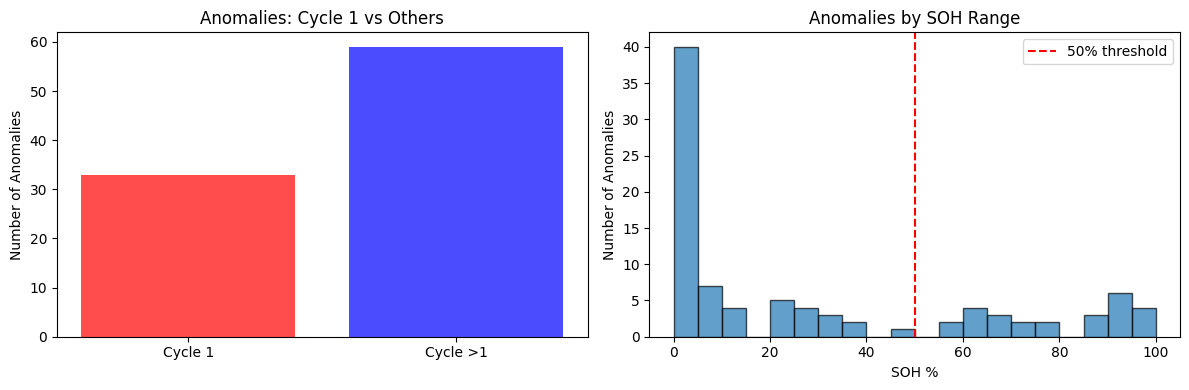

Cycle 1 anomalies: 33 out of 92 total anomalies (35.9%)
Self-discharge test files flagged: 0


In [11]:
import matplotlib.pyplot as plt

# Anomalies by cycle_number
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Cycle 1 vs others
cycle1_anomalies = anomalies[anomalies['cycle_number'] == 1]
other_anomalies = anomalies[anomalies['cycle_number'] > 1]

axes[0].bar(['Cycle 1', 'Cycle >1'], [len(cycle1_anomalies), len(other_anomalies)], 
            color=['red', 'blue'], alpha=0.7)
axes[0].set_ylabel('Number of Anomalies')
axes[0].set_title('Anomalies: Cycle 1 vs Others')

# Plot 2: Anomalies by SOH range
axes[1].hist(anomalies['soh_percent'], bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('SOH %')
axes[1].set_ylabel('Number of Anomalies')
axes[1].set_title('Anomalies by SOH Range')
axes[1].axvline(x=50, color='red', linestyle='--', label='50% threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Cycle 1 anomalies: {len(cycle1_anomalies)} out of {len(anomalies)} total anomalies ({len(cycle1_anomalies)/len(anomalies)*100:.1f}%)")
print(f"Self-discharge test files flagged: {anomalies[anomalies['source_file'].str.contains('self_discharge', case=False)].shape[0]}")

In [12]:
# Create filtered dataframe (exclude Cycle 1)
df_clean = df_feat[df_feat['cycle_number'] > 1].copy()

# Recalculate ensemble anomaly flag for filtered data
df_clean['anomaly_ensemble'] = ((df_clean['anomaly_if'] == -1).astype(int) + 
                                 (df_clean['anomaly_svm'] == -1).astype(int) + 
                                 (df_clean['anomaly_lof'] == -1).astype(int))

df_clean['is_anomaly'] = df_clean['anomaly_ensemble'] >= 2

print(f"After excluding Cycle 1:")
print(f"  Total cycles: {len(df_clean)}")
print(f"  Ensemble anomalies: {df_clean['is_anomaly'].sum()}")
print(f"  Anomaly rate: {df_clean['is_anomaly'].mean()*100:.2f}%")

# Display remaining anomalies
anomalies_clean = df_clean[df_clean['is_anomaly'] == True]
anomalies_display = anomalies_clean[['source_file', 'cycle_number', 'soh_percent', 
                                      'current_max_A', 'voltage_min_V', 'resistance_max_ohm', 
                                      'duration_seconds', 'anomaly_ensemble']]

print(f"\nRemaining anomalies (sorted by confidence):")
anomalies_display.sort_values('anomaly_ensemble', ascending=False).head(15)

After excluding Cycle 1:
  Total cycles: 1966
  Ensemble anomalies: 59
  Anomaly rate: 3.00%

Remaining anomalies (sorted by confidence):


,source_file,cycle_number,soh_percent,current_max_A,voltage_min_V,resistance_max_ohm,duration_seconds,anomaly_ensemble
56,CX2_16_10_18_11.xlsx,7,10.765841,1.2270,3.2621,0.0941,108868.5885,3
97,CX2_16_10_28_11.xlsx,41,62.826042,3.8798,3.2531,0.0747,623318.0139,3
140,CX2_16_10_4_11.xlsx,43,88.444387,1.0668,2.6999,0.0771,764742.0236,3
146,CX2_16_10_4_11.xlsx,49,98.334461,1.1795,2.6999,0.0899,860391.5481,3
142,CX2_16_10_4_11.xlsx,45,91.707686,1.2185,2.6999,0.0924,796363.6131,3
145,CX2_16_10_4_11.xlsx,48,96.671310,1.1962,2.6999,0.0877,844334.3195,3
144,CX2_16_10_4_11.xlsx,47,95.010398,1.1887,2.6999,0.0908,828293.6302,3
147,CX2_16_10_4_11.xlsx,50,100.000000,1.1858,2.6999,0.0884,876465.8667,3
338,CX2_16_2_25_11.xlsx,40,74.965699,1.2955,2.6999,0.0836,695042.2831,3
264,CX2_16_2_15_11.xlsx,16,30.286364,1.2858,2.6999,0.0827,275343.4521,3


In [13]:
import joblib
from pathlib import Path

# Create output directory
output_dir = Path("../../models/anomaly/saved_models")
output_dir.mkdir(parents=True, exist_ok=True)

# Save the Isolation Forest model (best performer)
joblib.dump(iso_forest, output_dir / "isolation_forest_cx2_16.joblib")
joblib.dump(scaler, output_dir / "scaler_cx2_16.joblib")

# Save the feature columns list
joblib.dump(feature_cols, output_dir / "feature_columns_cx2_16.joblib")

# Save the full dataframe with anomaly labels
df_feat.to_csv(output_dir / "cx2_16_with_anomalies.csv", index=False)

print(f"✅ Saved to: {output_dir}")
print(f"   - Isolation Forest model")
print(f"   - StandardScaler")
print(f"   - Feature columns")
print(f"   - Full labeled dataset")

✅ Saved to: ../../models/anomaly/saved_models
   - Isolation Forest model
   - StandardScaler
   - Feature columns
   - Full labeled dataset


In [14]:
# App-compatible features (11 features)
app_features = [
    'cycle_number',
    'current_mean_A', 
    'voltage_mean_V',
    'charge_capacity_Ah',
    'discharge_capacity_Ah',
    'duration_seconds',
    'soh_percent',
    'current_cv',
    'avg_power_W',
    'coulombic_efficiency',
    'source_file_encoded'
]

# Create feature matrix with only these features
X_app = df_feat[app_features].copy()

print(f"App-compatible feature matrix shape: {X_app.shape}")
print(f"\nFeatures used ({len(app_features)}):")
for i, col in enumerate(app_features, 1):
    print(f"  {i:2d}. {col}")

App-compatible feature matrix shape: (2018, 11)

Features used (11):
   1. cycle_number
   2. current_mean_A
   3. voltage_mean_V
   4. charge_capacity_Ah
   5. discharge_capacity_Ah
   6. duration_seconds
   7. soh_percent
   8. current_cv
   9. avg_power_W
  10. coulombic_efficiency
  11. source_file_encoded


In [15]:
# Scale the features
scaler_app = StandardScaler()
X_app_scaled = scaler_app.fit_transform(X_app)

# Train Isolation Forest
iso_forest_app = IsolationForest(
    contamination=0.05,
    random_state=42
)
iso_forest_app.fit(X_app_scaled)

# Get predictions
df_feat['anomaly_app'] = iso_forest_app.predict(X_app_scaled)
df_feat['anomaly_score_app'] = iso_forest_app.score_samples(X_app_scaled)

print(f"Model trained!")
print(f"Anomalies detected: {(df_feat['anomaly_app'] == -1).sum()} out of {len(df_feat)}")
print(f"Anomaly rate: {(df_feat['anomaly_app'] == -1).mean()*100:.2f}%")

Model trained!
Anomalies detected: 101 out of 2018
Anomaly rate: 5.00%


In [16]:
# Compare with the ensemble anomalies from before
df_feat['anomaly_full'] = df_feat['is_anomaly']  # From our ensemble model

# Agreement between full and app models
agreement = (df_feat['anomaly_app'] == -1) == df_feat['anomaly_full']
print(f"Agreement between 25-feature ensemble and 11-feature model: {agreement.mean()*100:.1f}%")

# Anomalies detected by both
both = ((df_feat['anomaly_app'] == -1) & (df_feat['anomaly_full'] == True)).sum()
print(f"Anomalies detected by both: {both}")

Agreement between 25-feature ensemble and 11-feature model: 97.6%
Anomalies detected by both: 72


In [17]:
import joblib

output_dir = Path("../../models/anomaly/saved_models")

# Save app-compatible model
joblib.dump(iso_forest_app, output_dir / "isolation_forest_app.joblib")
joblib.dump(scaler_app, output_dir / "scaler_app.joblib")
joblib.dump(app_features, output_dir / "feature_columns_app.joblib")

print(f"✅ Saved app-compatible model to: {output_dir}")
print(f"   - isolation_forest_app.joblib")
print(f"   - scaler_app.joblib")
print(f"   - feature_columns_app.joblib")

✅ Saved app-compatible model to: ../../models/anomaly/saved_models
   - isolation_forest_app.joblib
   - scaler_app.joblib
   - feature_columns_app.joblib


In [18]:
# Display the exact feature order expected by the model
print("INPUT FEATURES (must be in this exact order):")
print("-" * 50)
for i, col in enumerate(app_features, 1):
    print(f"{i:2d}. {col}")

print("\n" + "=" * 50)
print("EXPECTED INPUT FORMAT:")
print("=" * 50)
print("""
{
    "cycle_number": int,
    "current_mean_A": float,      // avg_current_ma / 1000
    "voltage_mean_V": float,      // avg_voltage_v
    "charge_capacity_Ah": float,  // mah_transferred / 1000 (charge sessions)
    "discharge_capacity_Ah": float, // mah_transferred / 1000 (discharge sessions)
    "duration_seconds": float,    // duration_minutes * 60
    "soh_percent": float,         // health_pct
    "current_cv": float,          // already calculated in app
    "avg_power_W": float,         // avg_voltage * avg_current (or from energy)
    "coulombic_efficiency": float, // discharge_capacity / charge_capacity
    "source_file_encoded": int    // device_id + session_start mapped to integer
}
""")

print("\n" + "=" * 50)
print("OUTPUT FORMAT:")
print("=" * 50)
print("""
{
    "is_anomaly": boolean,        // true if anomaly (-1), false if normal (1)
    "anomaly_score": float,       // lower = more anomalous (typically -0.3 to 0.1)
    "confidence": string          // "high" if score < -0.2, "medium" if -0.2 to -0.1, "low" if > -0.1
}
""")

INPUT FEATURES (must be in this exact order):
--------------------------------------------------
 1. cycle_number
 2. current_mean_A
 3. voltage_mean_V
 4. charge_capacity_Ah
 5. discharge_capacity_Ah
 6. duration_seconds
 7. soh_percent
 8. current_cv
 9. avg_power_W
10. coulombic_efficiency
11. source_file_encoded

EXPECTED INPUT FORMAT:

{
    "cycle_number": int,
    "current_mean_A": float,      // avg_current_ma / 1000
    "voltage_mean_V": float,      // avg_voltage_v
    "charge_capacity_Ah": float,  // mah_transferred / 1000 (charge sessions)
    "discharge_capacity_Ah": float, // mah_transferred / 1000 (discharge sessions)
    "duration_seconds": float,    // duration_minutes * 60
    "soh_percent": float,         // health_pct
    "current_cv": float,          // already calculated in app
    "avg_power_W": float,         // avg_voltage * avg_current (or from energy)
    "coulombic_efficiency": float, // discharge_capacity / charge_capacity
    "source_file_encoded": int    

In [20]:
# Run this in your notebook to create the classifier

# 1. Calculate feature statistics for the classifier
feature_stats = {}
for feature in app_features:
    values = df_feat[feature]
    feature_stats[feature] = {
        'median': float(values.median()),
        'q1': float(values.quantile(0.25)),
        'q3': float(values.quantile(0.75)),
        'iqr': float(values.quantile(0.75) - values.quantile(0.25)),
        'min': float(values.min()),
        'max': float(values.max()),
        'mean': float(values.mean()),
        'std': float(values.std())
    }

# 2. Define feature-to-anomaly mapping
feature_to_anomaly = {
    'soh_percent': {
        'high': 'unusually_high_capacity',
        'low': 'severe_capacity_degradation'
    },
    'current_mean_A': {
        'high': 'abnormal_charging_current',
        'low': 'abnormal_discharging_current'
    },
    'current_max_A': {
        'high': 'current_spike'
    },
    'voltage_mean_V': {
        'high': 'overvoltage_warning',
        'low': 'undervoltage_warning'
    },
    'voltage_min_V': {
        'low': 'deep_discharge_warning'
    },
    'duration_seconds': {
        'high': 'extended_cycle_duration',
        'low': 'abnormally_short_cycle'
    },
    'current_cv': {
        'high': 'current_instability'
    },
    'coulombic_efficiency': {
        'low': 'poor_charging_efficiency'
    },
    'avg_power_W': {
        'high': 'high_power_draw',
        'low': 'low_power_draw'
    }
}

# 3. Save the classifier
classifier_data = {
    'feature_stats': feature_stats,
    'feature_to_anomaly': feature_to_anomaly,
    'threshold': 2.0  # Minimum IQR deviation to consider significant
}

import joblib
output_dir = Path("../../models/anomaly/saved_models")
joblib.dump(classifier_data, output_dir / "anomaly_classifier.joblib")

print("✅ Classifier saved!")
print(f"   - {len(feature_stats)} features with normal ranges")
print(f"   - {len(feature_to_anomaly)} mapped anomaly types")

✅ Classifier saved!
   - 11 features with normal ranges
   - 9 mapped anomaly types
